#  Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("brand_sentiment_1000.csv")

## Basic Check

In [2]:
print("Shape: ", df.shape)
print(df.head())
print(df.columns)
print(df.sentiment.value_counts())
print(df.language.value_counts())

Shape:  (1000, 9)
   id                                               text language   platform  \
0   1        Idhu Customer service mass. Quick response.       ta    reviews   
1   2  Great service 👏 no response for 24 hours wait ...       en  instagram   
2   3              Idhu Return/refund smooth experience.       ta    reviews   
3   4            Idhu Courier smooth-a deliver pannanga.       ta    youtube   
4   5          Idhu Complaint raise panniten, no update.       ta    support   

  region        date    aspect sentiment  sarcasm  
0     MH  2026-02-15   service  positive        0  
1     TN  2025-12-02     price  negative        1  
2     TS  2025-12-29    refund  positive        0  
3     DL  2026-01-21  delivery  positive        0  
4     KL  2025-12-31   service  negative        0  
Index(['id', 'text', 'language', 'platform', 'region', 'date', 'aspect',
       'sentiment', 'sarcasm'],
      dtype='object')
sentiment
negative    504
positive    273
neutral     223
Name

# Data Cleaning

In [3]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove @mentions
    text = re.sub(r"@\w+", "", text)

    # remove '#' but keep hashtag word
    text = text.replace("#", "")

    # reduce repeated letters: sooooo -> soo
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

# quick check
df[["text", "clean_text"]].head(8)

,text,clean_text
0,Idhu Customer service mass. Quick response.,idhu customer service mass. quick response.
1,Great service 👏 no response for 24 hours wait ...,great service 👏 no response for 24 hours wait ...
2,Idhu Return/refund smooth experience.,idhu return/refund smooth experience.
3,Idhu Courier smooth-a deliver pannanga.,idhu courier smooth-a deliver pannanga.
4,"Idhu Complaint raise panniten, no update.","idhu complaint raise panniten, no update."
5,Great service 👏 1 day wait pannanum,great service 👏 1 day wait pannanum
6,"Idhu Packaging damage, product scratch.","idhu packaging damage, product scratch."
7,"Material good, value for money.","material good, value for money."


# Language Detection

In [4]:
from langdetect import detect

def detect_lang_safe(text):
    try:
        return detect(text)
    except:
        return "unknown"

df["detected_lang"] = df["clean_text"].apply(detect_lang_safe)

df[["clean_text", "language", "detected_lang"]].head(10)

,clean_text,language,detected_lang
0,idhu customer service mass. quick response.,ta,fr
1,great service 👏 no response for 24 hours wait ...,en,en
2,idhu return/refund smooth experience.,ta,en
3,idhu courier smooth-a deliver pannanga.,ta,en
4,"idhu complaint raise panniten, no update.",ta,fr
5,great service 👏 1 day wait pannanum,mix,en
6,"idhu packaging damage, product scratch.",ta,en
7,"material good, value for money.",mix,en
8,"refund romba slow, no response for 24 hours aa...",mix,en
9,box normal-a irundhuchu.,mix,en


# Cleaned Dataset Save

In [5]:
df.to_csv("brand_sentiment_1000_clean.csv", index=False, encoding="utf-8-sig")

print("Saved: brand_sentiment_1000_clean.csv")

Saved: brand_sentiment_1000_clean.csv


# Slang Dictionary

In [6]:
# Slang / internet words mapping
slang_map = {
    "mass": "very_good",
    "semma": "very_good",
    "vera level": "very_good",
    "worth": "worth",
    "super": "good",
    "mokka": "very_bad",
    "waste": "very_bad",
    "kadupu": "annoying",
    "romba mosam": "very_bad",
}

def apply_slang_map(text: str) -> str:
    t = text
    for k, v in slang_map.items():
        t = t.replace(k, v)
    return t

df["clean_text_slang"] = df["clean_text"].apply(apply_slang_map)

df[["clean_text", "clean_text_slang"]].head(10)

,clean_text,clean_text_slang
0,idhu customer service mass. quick response.,idhu customer service very_good. quick response.
1,great service 👏 no response for 24 hours wait ...,great service 👏 no response for 24 hours wait ...
2,idhu return/refund smooth experience.,idhu return/refund smooth experience.
3,idhu courier smooth-a deliver pannanga.,idhu courier smooth-a deliver pannanga.
4,"idhu complaint raise panniten, no update.","idhu complaint raise panniten, no update."
5,great service 👏 1 day wait pannanum,great service 👏 1 day wait pannanum
6,"idhu packaging damage, product scratch.","idhu packaging damage, product scratch."
7,"material good, value for money.","material good, value for money."
8,"refund romba slow, no response for 24 hours aa...","refund romba slow, no response for 24 hours aa..."
9,box normal-a irundhuchu.,box normal-a irundhuchu.


# Sarcasam Signal Features

In [7]:
import re

sarcasm_emojis = ["🙃", "😏", "👏"]
sarcasm_words = ["wow", "great", "amazing", "sure", "yeah right"]
negative_cues = ["very_bad", "worst", "bad", "broken", "no response", "late", "delay", "annoying"]

def sarcasm_signal(text: str) -> int:
    t = str(text).lower()
    score = 0

    # emoji signals
    for e in sarcasm_emojis:
        if e in t:
            score += 2

    # sarcasm words
    for w in sarcasm_words:
        if w in t:
            score += 1

    # negative cues
    for n in negative_cues:
        if n in t:
            score += 1

    # punctuation patterns
    if "..." in t:
        score += 1
    if t.count("!") >= 2:
        score += 1

    return score

df["sarcasm_signal"] = df["clean_text_slang"].apply(sarcasm_signal)

df[["clean_text_slang", "sarcasm", "sarcasm_signal"]].head(15)

,clean_text_slang,sarcasm,sarcasm_signal
0,idhu customer service very_good. quick response.,0,0
1,great service 👏 no response for 24 hours wait ...,1,4
2,idhu return/refund smooth experience.,0,0
3,idhu courier smooth-a deliver pannanga.,0,0
4,"idhu complaint raise panniten, no update.",0,0
5,great service 👏 1 day wait pannanum,1,3
6,"idhu packaging damage, product scratch.",0,0
7,"material good, value for money.",0,0
8,"refund romba slow, no response for 24 hours aa...",0,1
9,box normal-a irundhuchu.,0,0


# Aspect Key Extraction

In [8]:
aspect_keywords = {
    "delivery": ["delivery", "courier", "late", "delay", "tracking"],
    "price": ["price", "cost", "expensive", "cheap", "offer", "deal"],
    "quality": ["quality", "broken", "broke", "damage", "durable", "material"],
    "service": ["support", "service", "customer care", "reply", "response", "ticket"],
    "packaging": ["pack", "packing", "box", "wrap", "scratch"],
    "app": ["app", "login", "payment", "crash", "bug", "ui"],
    "refund": ["refund", "return", "replacement", "cancel"],
}

def extract_aspects(text: str):
    t = str(text).lower()
    found = []
    for asp, keys in aspect_keywords.items():
        if any(k in t for k in keys):
            found.append(asp)
    return found if found else ["unknown"]

df["extracted_aspects"] = df["clean_text_slang"].apply(extract_aspects)

df[["clean_text_slang", "aspect", "extracted_aspects"]].head(15)

,clean_text_slang,aspect,extracted_aspects
0,idhu customer service very_good. quick response.,service,"[service, app]"
1,great service 👏 no response for 24 hours wait ...,price,[service]
2,idhu return/refund smooth experience.,refund,[refund]
3,idhu courier smooth-a deliver pannanga.,delivery,[delivery]
4,"idhu complaint raise panniten, no update.",service,[unknown]
5,great service 👏 1 day wait pannanum,quality,[service]
6,"idhu packaging damage, product scratch.",packaging,"[quality, packaging]"
7,"material good, value for money.",quality,[quality]
8,"refund romba slow, no response for 24 hours aa...",refund,"[service, refund]"
9,box normal-a irundhuchu.,packaging,[packaging]


# Aspect Sentiment Hint

In [9]:
positive_cues = ["good", "very_good", "super", "excellent", "worth", "fast", "helpful", "smooth", "on-time", "satisfied"]
negative_cues = ["very_bad", "worst", "bad", "cheap", "broken", "broke", "damage", "late", "delay", "no response", "annoying", "refund slow"]

def aspect_sentiment_hints(text: str):
    t = str(text).lower()
    aspects_found = extract_aspects(t)

    # overall cue counts
    pos = sum(1 for w in positive_cues if w in t)
    neg = sum(1 for w in negative_cues if w in t)

    # create hint per aspect (simple: same score used for all found aspects)
    result = {}
    for asp in aspects_found:
        if pos > neg:
            result[asp] = "positive_hint"
        elif neg > pos:
            result[asp] = "negative_hint"
        else:
            result[asp] = "neutral_hint"
    return result

df["aspect_sentiment_hint"] = df["clean_text_slang"].apply(aspect_sentiment_hints)

df[["clean_text_slang", "extracted_aspects", "aspect_sentiment_hint"]].head(12)

,clean_text_slang,extracted_aspects,aspect_sentiment_hint
0,idhu customer service very_good. quick response.,"[service, app]","{'service': 'positive_hint', 'app': 'positive_..."
1,great service 👏 no response for 24 hours wait ...,[service],{'service': 'negative_hint'}
2,idhu return/refund smooth experience.,[refund],{'refund': 'positive_hint'}
3,idhu courier smooth-a deliver pannanga.,[delivery],{'delivery': 'positive_hint'}
4,"idhu complaint raise panniten, no update.",[unknown],{'unknown': 'neutral_hint'}
5,great service 👏 1 day wait pannanum,[service],{'service': 'neutral_hint'}
6,"idhu packaging damage, product scratch.","[quality, packaging]","{'quality': 'negative_hint', 'packaging': 'neg..."
7,"material good, value for money.",[quality],{'quality': 'positive_hint'}
8,"refund romba slow, no response for 24 hours aa...","[service, refund]","{'service': 'negative_hint', 'refund': 'negati..."
9,box normal-a irundhuchu.,[packaging],{'packaging': 'neutral_hint'}


# Overall Sentiment Distribution

In [10]:
sentiment_percent = df["sentiment"].value_counts(normalize=True) * 100
sentiment_percent

sentiment
negative    50.4
positive    27.3
neutral     22.3
Name: proportion, dtype: float64

# Region wise Negative Analysis

In [16]:
region_sentiment = df.groupby(['region','sentiment']).size().unstack(fill_value=0)

region_sentiment["negative_percentage"] = (
    region_sentiment["negative"] / region_sentiment.sum(axis=1)
) * 100
region_sentiment.sort_values("negative_percentage", ascending=False)

sentiment,negative,neutral,positive,negative_percentage
region,,,,
KL,73,27,34,54.477612
TN,72,28,35,53.333333
KA,76,31,40,51.700680
AP,75,40,33,50.675676
DL,76,33,41,50.666667
MH,72,34,45,47.682119
TS,60,30,45,44.444444


# Aspect wise Complaint Analysis

In [19]:
aspect_sentiment = df.groupby(["aspect","sentiment"]).size().unstack(fill_value=0)

aspect_sentiment["negative_percentage"] = (
    aspect_sentiment["negative"] / aspect_sentiment.sum(axis = 1)
) * 100

aspect_sentiment.sort_values("negative_percentage", ascending=False)

sentiment,negative,neutral,positive,negative_percentage
aspect,,,,
quality,76,33,33,53.521127
service,79,34,41,51.298701
refund,70,29,39,50.724638
price,74,28,45,50.340136
delivery,61,22,40,49.593496
packaging,70,37,36,48.951049
app,74,40,39,48.366013


# Sentiment Trend Over time

In [21]:
df["date"] = pd.to_datetime(df["date"])

daily_sentiment = df.groupby(["date","sentiment"]).size().unstack(fill_value=0)

daily_sentiment.tail(10)

sentiment,negative,neutral,positive
date,,,
2026-02-16,6,3,0
2026-02-17,6,5,6
2026-02-18,5,1,3
2026-02-19,9,2,4
2026-02-20,4,2,2
2026-02-21,3,1,4
2026-02-22,3,5,3
2026-02-23,6,4,1
2026-02-24,5,5,6


# Sentiment Trend Over Time

In [24]:
last_date = df["date"].max()

last_7 = df[df["date"] >= last_date - pd.Timedelta(days=7)]
prev_7 = df[
    (df["date"] < last_date - pd.Timedelta(days=7))&
    (df["date"] >= last_date - pd.Timedelta(days=14))
]

last_7_neg_percent = (
    last_7["sentiment"].value_counts(normalize=True).get("negative",0) * 100
)

prev_7_neg_percent = (
    prev_7["sentiment"].value_counts(normalize=True).get("negative",0) * 100
)

print("Last 7 days Negative %:", last_7_neg_percent)
print("Previous 7 days Negative %:", prev_7_neg_percent)

Last 7 days Negative %: 41.11111111111111
Previous 7 days Negative %: 41.66666666666667


# Model Training

# Train/Test Split

In [27]:
from sklearn.model_selection import train_test_split

X = df["clean_text_slang"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train sentiment distribution:\n", y_train.value_counts(normalize=True)*100)
print("Test sentiment distribution:\n", y_test.value_counts(normalize=True)*100)

Train size: 800
Test size: 200
Train sentiment distribution:
 sentiment
negative    50.375
positive    27.375
neutral     22.250
Name: proportion, dtype: float64
Test sentiment distribution:
 sentiment
negative    50.5
positive    27.0
neutral     22.5
Name: proportion, dtype: float64


# TF-IDF Vectorization (Text → Numbers)

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

# Word-level TF-IDF
word_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Character-level TF-IDF (best for typos + Tanglish)
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",     # char within word boundaries
    ngram_range=(3, 5),     # 3-5 char grams
    min_df=2
)

# Combine both
vectorizer = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

X_train_vec2 = vectorizer.fit_transform(X_train)
X_test_vec2 = vectorizer.transform(X_test)

print("✅ New Train vector shape:", X_train_vec2.shape)
print("✅ New Test vector shape:", X_test_vec2.shape)

✅ New Train vector shape: (800, 3082)
✅ New Test vector shape: (200, 3082)


# Train Logistic Regression Model

In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

print("Model Trained Successfully")

Model Trained Successfully


# Model Accuracy + Classification Report

In [45]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()

svm_model.fit(X_train_vec2, y_train)

y_pred2 = svm_model.predict(X_test_vec2)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred2))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       101
     neutral       1.00      1.00      1.00        45
    positive       1.00      1.00      1.00        54

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# Confusion Matrix

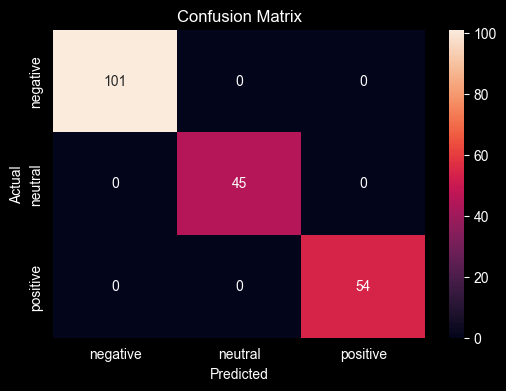

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Predict Sentiment for New Text

In [47]:
def predict_sentiment(text):
    # Step 1: clean
    cleaned = clean_text(text)

    # Step 2: slang normalize
    cleaned = apply_slang_map(cleaned)

    # Step 3: vectorize
    vec = tfidf.transform([cleaned])

    # Step 4: predict
    prediction = model.predict(vec)[0]
    probability = model.predict_proba(vec).max()

    return prediction, probability


# Try with custom text
sample_text = "Good Service, but quality can be improved"

pred, prob = predict_sentiment(sample_text)

print("Text:", sample_text)
print("Predicted Sentiment:", pred)
print("Confidence:", round(prob, 3))

Text: Good Service, but quality can be improved
Predicted Sentiment: negative
Confidence: 0.509


In [43]:
# Bulk prediction on full cleaned dataset

all_vec = tfidf.transform(df["clean_text_slang"])

df["predicted_sentiment"] = model.predict(all_vec)
df["confidence"] = model.predict_proba(all_vec).max(axis=1)

df[["text", "sentiment", "predicted_sentiment", "confidence"]].head(10)

,text,sentiment,predicted_sentiment,confidence
0,Idhu Customer service mass. Quick response.,positive,positive,0.841818
1,Great service 👏 no response for 24 hours wait ...,negative,negative,0.934055
2,Idhu Return/refund smooth experience.,positive,positive,0.786234
3,Idhu Courier smooth-a deliver pannanga.,positive,positive,0.859133
4,"Idhu Complaint raise panniten, no update.",negative,negative,0.920136
5,Great service 👏 1 day wait pannanum,negative,negative,0.945834
6,"Idhu Packaging damage, product scratch.",negative,negative,0.852297
7,"Material good, value for money.",positive,positive,0.899762
8,"Refund romba slow, no response for 24 hours aa...",negative,negative,0.895143
9,Box normal-a irundhuchu.,neutral,neutral,0.824016


In [36]:
df.to_csv("brand_sentiment_predictions.csv", index=False, encoding="utf-8-sig")

print(" Saved: brand_sentiment_predictions.csv")

 Saved: brand_sentiment_predictions.csv


In [44]:
import joblib

joblib.dump(model, "sentiment_model.joblib")
joblib.dump(tfidf, "tfidf_vectorizer.joblib")

print("Saved successfully")

Saved successfully


In [48]:
hard_texts = [
    "Not good at all, waste money",
    "Quality super but delivery worst 😡",
    "Camera ok ok, battery romba mosam",
    "Wow great… stopped working in 1 day 🙃",
    "Service response fast, but refund still pending",
    "Packaging torn, product scratch... very bad",
    "Semmmaaa product, vera level 😍",
    "Delivery on time, but item missing parts",
    "Price high but quality nalla iruku",
    "No response from support for 24 hours 👏",
    "App crash again and again, kadupu",
    "Not bad, but not great either",
    "I love the product ❤️ worth it",
    "Refund came quickly, good service",
    "Cheap feel, broke in two days",
    "Super deal offer, happy purchase",
    "Average product, nothing special",
    "Late delivery but customer care solved it",
    "Great service! waited 2 hours 👏",
    "Product received today. Will test later."
]

hard_df = pd.DataFrame({"text": hard_texts})
hard_df["clean"] = hard_df["text"].apply(clean_text).apply(apply_slang_map)
hard_df.head()

,text,clean
0,"Not good at all, waste money","not good at all, very_bad money"
1,Quality super but delivery worst 😡,quality good but delivery worst 😡
2,"Camera ok ok, battery romba mosam","camera ok ok, battery very_bad"
3,Wow great… stopped working in 1 day 🙃,wow great… stopped working in 1 day 🙃
4,"Service response fast, but refund still pending","service response fast, but refund still pending"


In [49]:
# Old model prediction (LogisticRegression + old tfidf)
old_vec = tfidf.transform(hard_df["clean"])
hard_df["old_pred"] = model.predict(old_vec)

# New model prediction (SVM + new vectorizer)
new_vec = vectorizer.transform(hard_df["clean"])
hard_df["new_pred"] = svm_model.predict(new_vec)

hard_df[["text", "old_pred", "new_pred"]]

,text,old_pred,new_pred
0,"Not good at all, waste money",negative,negative
1,Quality super but delivery worst 😡,negative,negative
2,"Camera ok ok, battery romba mosam",neutral,negative
3,Wow great… stopped working in 1 day 🙃,negative,negative
4,"Service response fast, but refund still pending",positive,neutral
5,"Packaging torn, product scratch... very bad",negative,negative
6,"Semmmaaa product, vera level 😍",positive,positive
7,"Delivery on time, but item missing parts",negative,negative
8,Price high but quality nalla iruku,negative,negative
9,No response from support for 24 hours 👏,negative,negative


In [50]:
diff_count = (hard_df["old_pred"] != hard_df["new_pred"]).sum()
print("Different predictions count:", diff_count)

hard_df[hard_df["old_pred"] != hard_df["new_pred"]][["text", "old_pred", "new_pred"]]

Different predictions count: 3


,text,old_pred,new_pred
2,"Camera ok ok, battery romba mosam",neutral,negative
4,"Service response fast, but refund still pending",positive,neutral
12,I love the product ❤️ worth it,negative,positive


In [51]:
import re

negation_words = ["not", "no", "never", "cannot", "can't", "dont", "don't", "didnt", "didn't"]

def handle_negation(text: str) -> str:
    t = str(text).lower()

    # normalize common forms
    t = t.replace("can’t", "can't").replace("don’t", "don't").replace("didn’t", "didn't")

    # join negation + next word => not_good
    # Example: "not good" -> "not_good"
    t = re.sub(r"\b(not|no|never|cannot|can't|dont|don't|didnt|didn't)\s+(\w+)\b", r"\1_\2", t)

    return t

# quick test
tests = [
    "not good at all",
    "no response from support",
    "never buy again",
    "don't like this product",
    "can't recommend"
]
for s in tests:
    print(s, "=>", handle_negation(s))

not good at all => not_good at all
no response from support => no_response from support
never buy again => never_buy again
don't like this product => don't_like this product
can't recommend => can't_recommend


In [52]:
# Apply new pipeline
df["clean_text_neg"] = (
    df["text"]
    .apply(clean_text)
    .apply(handle_negation)
    .apply(apply_slang_map)
)

df[["text", "clean_text_neg"]].head(10)

,text,clean_text_neg
0,Idhu Customer service mass. Quick response.,idhu customer service very_good. quick response.
1,Great service 👏 no response for 24 hours wait ...,great service 👏 no_response for 24 hours wait ...
2,Idhu Return/refund smooth experience.,idhu return/refund smooth experience.
3,Idhu Courier smooth-a deliver pannanga.,idhu courier smooth-a deliver pannanga.
4,"Idhu Complaint raise panniten, no update.","idhu complaint raise panniten, no_update."
5,Great service 👏 1 day wait pannanum,great service 👏 1 day wait pannanum
6,"Idhu Packaging damage, product scratch.","idhu packaging damage, product scratch."
7,"Material good, value for money.","material good, value for money."
8,"Refund romba slow, no response for 24 hours aa...","refund romba slow, no_response for 24 hours aa..."
9,Box normal-a irundhuchu.,box normal-a irundhuchu.


In [53]:
from sklearn.model_selection import train_test_split

X2 = df["clean_text_neg"]
y2 = df["sentiment"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Train size:", len(X_train2))
print("Test size:", len(X_test2))

Train size: 800
Test size: 200


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

word_tfidf2 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

char_tfidf2 = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2
)

vectorizer2 = FeatureUnion([
    ("word", word_tfidf2),
    ("char", char_tfidf2)
])

X_train_vec3 = vectorizer2.fit_transform(X_train2)
X_test_vec3 = vectorizer2.transform(X_test2)

print("New vector shape:", X_train_vec3.shape)

New vector shape: (800, 3142)


In [55]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm_model2 = LinearSVC()
svm_model2.fit(X_train_vec3, y_train2)

y_pred3 = svm_model2.predict(X_test_vec3)

print(classification_report(y_test2, y_pred3))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       101
     neutral       1.00      1.00      1.00        45
    positive       1.00      1.00      1.00        54

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [56]:
neg_tests = [
    "not good at all, waste money",
    "not bad, decent product",
    "no response from support for 24 hours",
    "never buy again, worst delivery",
    "don't like this, very bad quality",
    "can't recommend, app crash and delay"
]

neg_df = pd.DataFrame({"text": neg_tests})

# Apply same preprocessing pipelines
neg_df["base_clean"] = neg_df["text"].apply(clean_text).apply(apply_slang_map)
neg_df["neg_clean"] = neg_df["text"].apply(clean_text).apply(handle_negation).apply(apply_slang_map)

# Old model predictions (before negation integration)
old_vec = vectorizer.transform(neg_df["base_clean"])
neg_df["old_pred"] = svm_model.predict(old_vec)

# New model predictions (with negation integration)
new_vec = vectorizer2.transform(neg_df["neg_clean"])
neg_df["new_pred"] = svm_model2.predict(new_vec)

neg_df[["text", "base_clean", "neg_clean", "old_pred", "new_pred"]]

,text,base_clean,neg_clean,old_pred,new_pred
0,"not good at all, waste money","not good at all, very_bad money","not_good at all, very_bad money",negative,negative
1,"not bad, decent product","not bad, decent product","not_bad, decent product",negative,negative
2,no response from support for 24 hours,no response from support for 24 hours,no_response from support for 24 hours,negative,negative
3,"never buy again, worst delivery","never buy again, worst delivery","never_buy again, worst delivery",negative,negative
4,"don't like this, very bad quality","don't like this, very bad quality","don't_like this, very bad quality",negative,negative
5,"can't recommend, app crash and delay","can't recommend, app crash and delay","can't_recommend, app crash and delay",negative,negative


In [57]:
import pandas as pd

# 1) Create extra neutral + mixed samples (label them as NEUTRAL)
extra_neutral = [
    "not bad, decent product",
    "not great, not terrible",
    "ok ok product, average experience",
    "quality ok but nothing special",
    "delivery ok, product average",
    "service ok, response took some time",
    "received today, will test later",
    "product is fine, no major issues",
    "price ok, features average",
    "not worth hype, but usable",
    "camera ok, battery ok, overall normal",
    "good but not satisfied fully",
    "packing ok, product looks fine",
    "support replied, but slow process",
    "app works, sometimes slow",
    "not good not bad, just normal",
    "decent, could be better",
    "expected more, but ok",
    "fine for the price, average",
    "works as described, nothing extra",
]

extra_df = pd.DataFrame({
    "text": extra_neutral,
    "sentiment": ["neutral"] * len(extra_neutral)
})

# 2) Preprocess with SAME pipeline you used for improved model
extra_df["clean_text_neg"] = (
    extra_df["text"]
    .apply(clean_text)
    .apply(handle_negation)
    .apply(apply_slang_map)
)

# 3) Append to main df (only the columns needed for training)
# We'll keep existing df and add new rows for training
df_aug = pd.concat([df, extra_df], ignore_index=True)

print("Old size:", len(df))
print("New size:", len(df_aug))
print(df_aug["sentiment"].value_counts())

Old size: 1000
New size: 1020
sentiment
negative    504
positive    273
neutral     243
Name: count, dtype: int64


In [58]:
from sklearn.model_selection import train_test_split

X3 = df_aug["clean_text_neg"]
y3 = df_aug["sentiment"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

print("Train size:", len(X_train3))
print("Test size:", len(X_test3))
print(y3.value_counts())

Train size: 816
Test size: 204
sentiment
negative    504
positive    273
neutral     243
Name: count, dtype: int64


In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

word_tfidf3 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

char_tfidf3 = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2
)

vectorizer3 = FeatureUnion([
    ("word", word_tfidf3),
    ("char", char_tfidf3)
])

X_train_vec4 = vectorizer3.fit_transform(X_train3)
X_test_vec4 = vectorizer3.transform(X_test3)

print("New vector shape:", X_train_vec4.shape)

New vector shape: (816, 3266)


In [60]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm_model3 = LinearSVC()
svm_model3.fit(X_train_vec4, y_train3)

y_pred4 = svm_model3.predict(X_test_vec4)

print(classification_report(y_test3, y_pred4))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       101
     neutral       1.00      1.00      1.00        49
    positive       1.00      1.00      1.00        54

    accuracy                           1.00       204
   macro avg       1.00      1.00      1.00       204
weighted avg       1.00      1.00      1.00       204



In [61]:
check_texts = [
    "not bad, decent product",
    "not great, not terrible",
    "ok ok product, average experience",
    "good but not satisfied fully",
    "service ok, response took some time",
    "Delivery romba late, worst 😡",           # should be negative
    "I love the product ❤️ worth it",         # should be positive
]

check_df = pd.DataFrame({"text": check_texts})

check_df["clean"] = (
    check_df["text"]
    .apply(clean_text)
    .apply(handle_negation)
    .apply(apply_slang_map)
)

vec = vectorizer3.transform(check_df["clean"])
check_df["pred"] = svm_model3.predict(vec)

check_df[["text", "clean", "pred"]]

,text,clean,pred
0,"not bad, decent product","not_bad, decent product",neutral
1,"not great, not terrible","not_great, not_terrible",neutral
2,"ok ok product, average experience","ok ok product, average experience",neutral
3,good but not satisfied fully,good but not_satisfied fully,neutral
4,"service ok, response took some time","service ok, response took some time",neutral
5,"Delivery romba late, worst 😡","delivery romba late, worst 😡",negative
6,I love the product ❤️ worth it,i love the product ❤️ worth it,positive


In [62]:
import joblib

joblib.dump(svm_model3, "sentiment_model.joblib")
joblib.dump(vectorizer3, "tfidf_vectorizer.joblib")

print("✅ Updated model saved: sentiment_model.joblib, tfidf_vectorizer.joblib")

✅ Updated model saved: sentiment_model.joblib, tfidf_vectorizer.joblib


In [63]:
# Mild complaint / mixed but neutral (teach model)
mild_neutral = [
    "Good service but quality needs improvement",
    "Good product but could be better",
    "Nice service but quality can be improved",
    "Delivery was fine but packaging could improve",
    "Works fine but not perfect",
    "Satisfied overall but minor issues",
    "Good quality but price a bit high",
    "Service good but response time could be faster",
    "Product ok but performance can be improved",
    "Not satisfied fully but overall ok",
    "Camera good but battery needs improvement",
    "Support is good but refund process needs improvement",
    "Good but there is room for improvement",
    "Good experience but still needs improvements",
    "Everything ok but quality could be better",
]

mild_df = pd.DataFrame({"text": mild_neutral, "sentiment": ["neutral"] * len(mild_neutral)})

# Apply SAME preprocessing pipeline (clean → negation → slang)
mild_df["clean_text_neg"] = (
    mild_df["text"]
    .apply(clean_text)
    .apply(handle_negation)
    .apply(apply_slang_map)
)

# Append to augmented dataset
df_aug2 = pd.concat([df_aug, mild_df], ignore_index=True)

print("Old augmented size:", len(df_aug))
print("New augmented size:", len(df_aug2))
print(df_aug2["sentiment"].value_counts())

Old augmented size: 1020
New augmented size: 1035
sentiment
negative    504
positive    273
neutral     258
Name: count, dtype: int64


In [64]:
from sklearn.model_selection import train_test_split

X4 = df_aug2["clean_text_neg"]
y4 = df_aug2["sentiment"]

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X4, y4, test_size=0.2, random_state=42, stratify=y4
)

print(y4.value_counts())

sentiment
negative    504
positive    273
neutral     258
Name: count, dtype: int64


In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC

word_tfidf4 = TfidfVectorizer(max_features=6000, ngram_range=(1, 2))
char_tfidf4 = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2)

vectorizer4 = FeatureUnion([
    ("word", word_tfidf4),
    ("char", char_tfidf4)
])

X_train_vec5 = vectorizer4.fit_transform(X_train4)
X_test_vec5 = vectorizer4.transform(X_test4)

svm_model4 = LinearSVC()
svm_model4.fit(X_train_vec5, y_train4)

print("✅ Retrained svm_model4")

✅ Retrained svm_model4


In [66]:
test_sentence = "Good service but quality needs improvement"

test_clean = apply_slang_map(handle_negation(clean_text(test_sentence)))
test_vec = vectorizer4.transform([test_clean])

pred = svm_model4.predict(test_vec)[0]

print("Text:", test_sentence)
print("Clean:", test_clean)
print("Prediction:", pred)

Text: Good service but quality needs improvement
Clean: good service but quality needs improvement
Prediction: neutral


In [67]:
import joblib

joblib.dump(svm_model4, "sentiment_model.joblib")
joblib.dump(vectorizer4, "tfidf_vectorizer.joblib")

print("✅ Saved updated model + vectorizer")

✅ Saved updated model + vectorizer
